In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
filename = 'yearly_full_release_long_format.csv'
df_init = pd.read_csv(filename)
print(df_init.describe())

                Year             EU           OECD            G20  \
count  370961.000000  348848.000000  348848.000000  348848.000000   
mean     2012.179628       0.131046       0.182747       0.087608   
std         7.295586       0.337451       0.386460       0.282725   
min      2000.000000       0.000000       0.000000       0.000000   
25%      2006.000000       0.000000       0.000000       0.000000   
50%      2012.000000       0.000000       0.000000       0.000000   
75%      2018.000000       0.000000       0.000000       0.000000   
max      2025.000000       1.000000       1.000000       1.000000   

                  G7          ASEAN          Value  YoY absolute change  \
count  348848.000000  348848.000000  350593.000000        255683.000000   
mean        0.033476       0.048098      70.737081             2.017624   
std         0.179876       0.213974     605.682082            28.231896   
min         0.000000       0.000000     -92.680000          -500.000000   
25%

In [4]:
# to remove missing values from important columns
important_cols = ['Year', 'Value']
df_init = df_init.dropna(subset=important_cols)

# convert numeric columns
numeric_cols = ['Value']
new_cols = ['Value (norm)']
df_init[new_cols] = df_init[numeric_cols].apply(lambda x: np.log10(x) if np.issubdtype(x.dtype, np.number) else x)

for col in numeric_cols:
    if col in df_init.columns:
        df_init[col] = pd.to_numeric(df_init[col], errors='coerce')

# convert year
if 'Year' in df_init.columns:
    df_init['Year'] = pd.to_numeric(df_init['Year'], errors='coerce')


c:\Users\iancu\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\iancu\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
df_pivot = pd.pivot_table(df_init, index=["Area","Area type","Continent","Year"], values="Value", columns=["Variable", "Unit"])

new_row = []
for a,b in df_pivot.columns:
    new_row.append(str(a+'('+b+')'))

df_pivot.columns = new_row
df_pivot.to_csv("pivot.csv")
df = pd.read_csv("pivot.csv")

numeric_cols = new_row

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# convert year
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

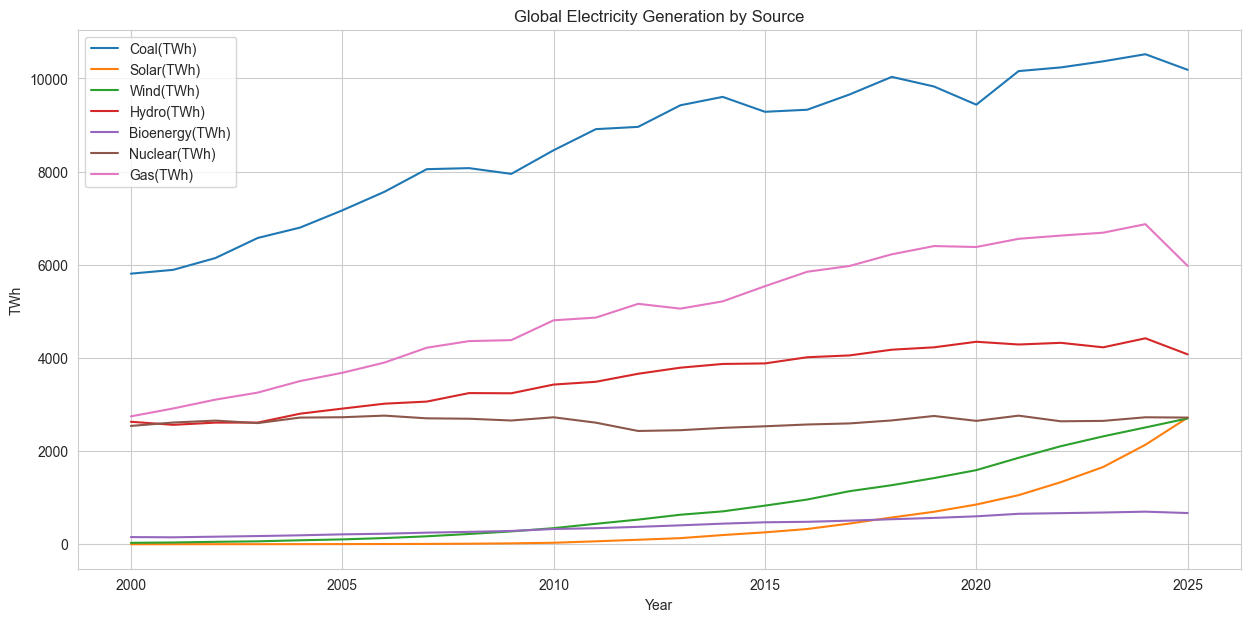

In [6]:
twh_cols = ['Coal(TWh)','Solar(TWh)','Wind(TWh)','Hydro(TWh)','Bioenergy(TWh)','Nuclear(TWh)','Gas(TWh)']

generation = (
    df.groupby('Year')[twh_cols]
    .sum()
)
generation.plot(figsize=(15,7))

plt.title('Global Electricity Generation by Source')
plt.ylabel('TWh')
plt.xlabel('Year')

plt.show()

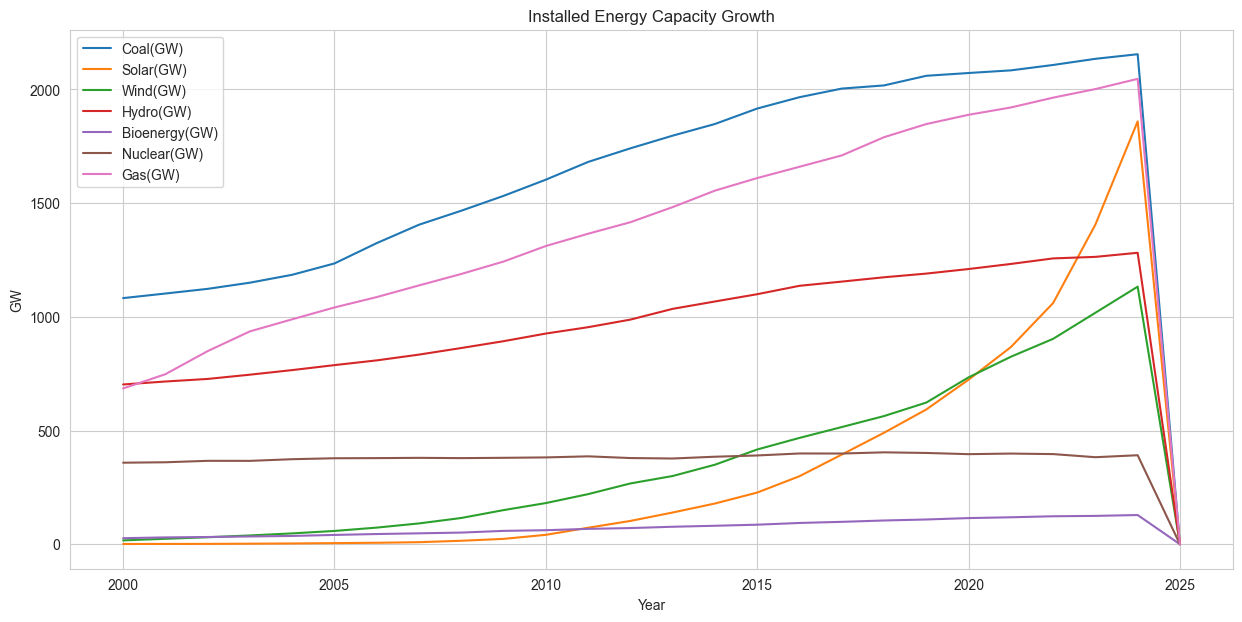

In [7]:
gw_cols = ['Coal(GW)','Solar(GW)','Wind(GW)','Hydro(GW)','Bioenergy(GW)','Nuclear(GW)','Gas(GW)']

capacity = (
    df.groupby('Year')[gw_cols]
    .sum()
)

capacity.plot(figsize=(15,7))

plt.title('Installed Energy Capacity Growth')
plt.ylabel('GW')

plt.show()

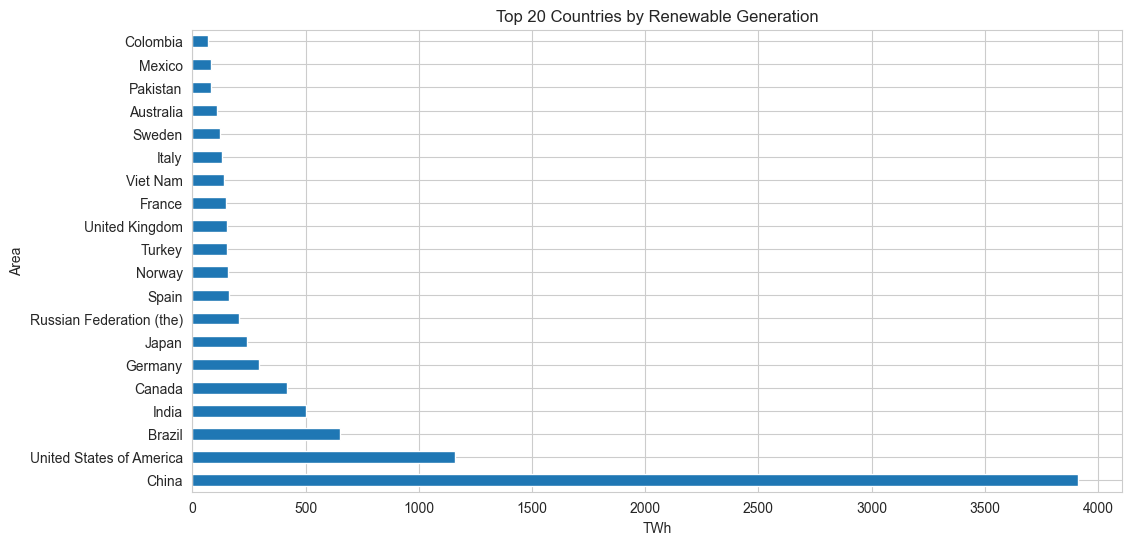

In [8]:
renew_col = 'Renewables(TWh)'

latest_year = df['Year'].max()

latest = df[df['Year'] == latest_year]

top_solar = (
    latest.groupby('Area')[renew_col]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_solar.plot(kind='barh', figsize=(12,6))

plt.title('Top 20 Countries by Renewable Generation')
plt.xlabel('TWh')

plt.show()

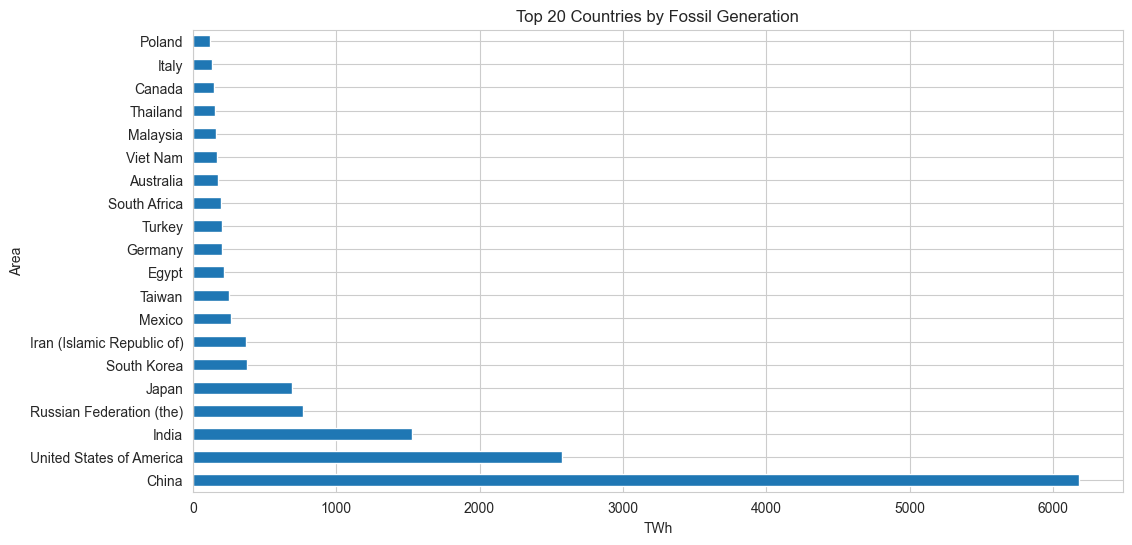

In [9]:
fossil_col = 'Fossil(TWh)'

latest_year = df['Year'].max()

latest = df[df['Year'] == latest_year]

top_solar = (
    latest.groupby('Area')[fossil_col]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_solar.plot(kind='barh', figsize=(12,6))

plt.title('Top 20 Countries by Fossil Generation')
plt.xlabel('TWh')

plt.show()

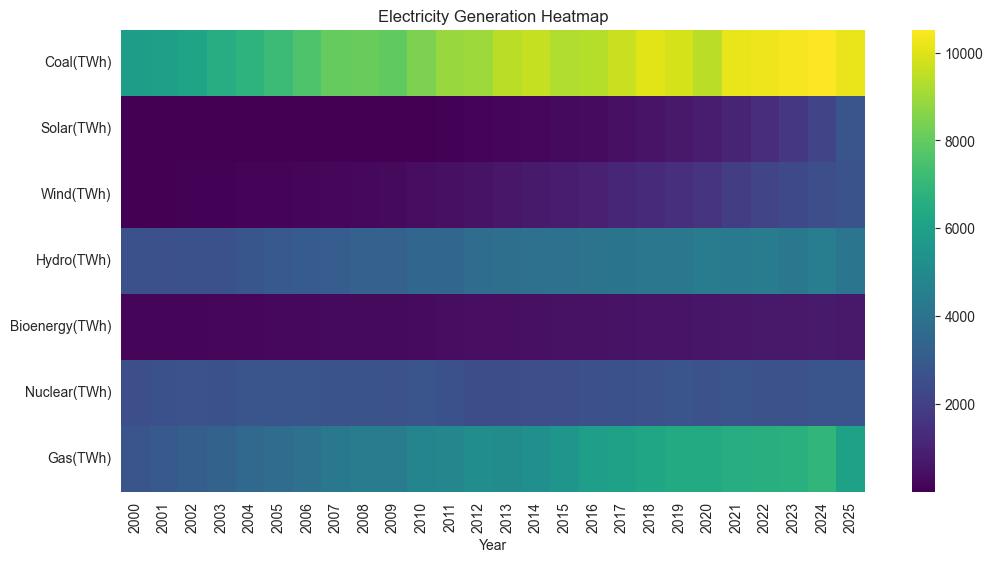

In [10]:
energy_cols = ['Coal(TWh)','Solar(TWh)','Wind(TWh)','Hydro(TWh)','Bioenergy(TWh)','Nuclear(TWh)','Gas(TWh)']

heatmap_data = (
    df.groupby('Year')[energy_cols]
    .sum()
)

sns.heatmap(heatmap_data.T, cmap='viridis')
plt.title('Electricity Generation Heatmap')
plt.show()

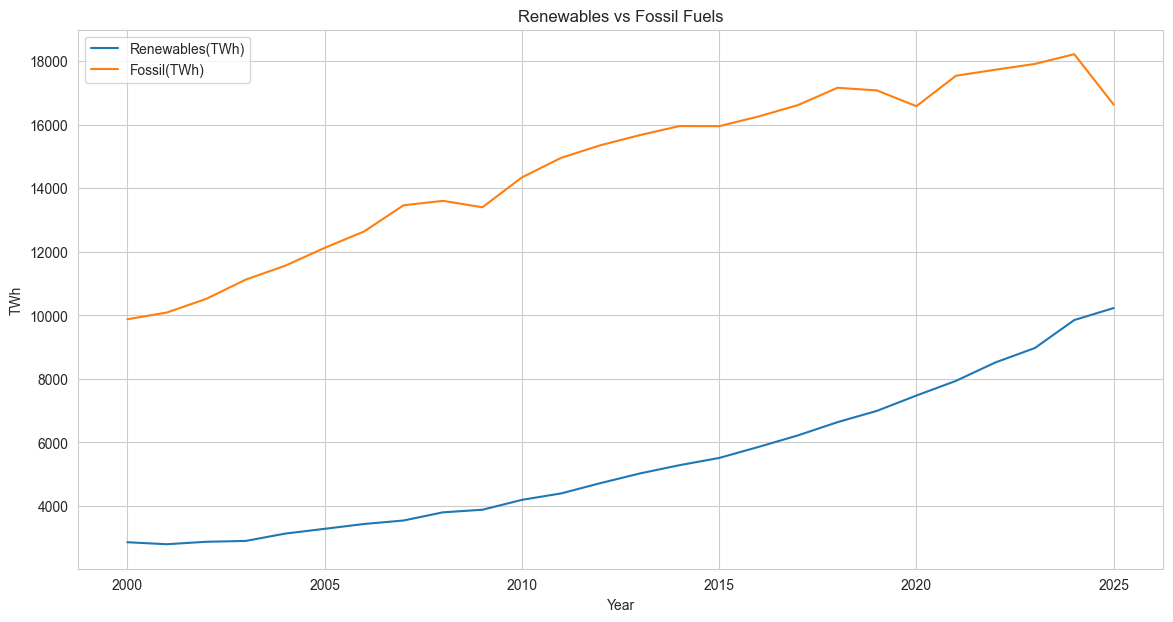

In [11]:
comparison = (
    df.groupby('Year')[['Renewables(TWh)', 'Fossil(TWh)']]
    .sum()
)

comparison.plot(figsize=(14,7))

plt.title('Renewables vs Fossil Fuels')
plt.ylabel('TWh')
plt.show()

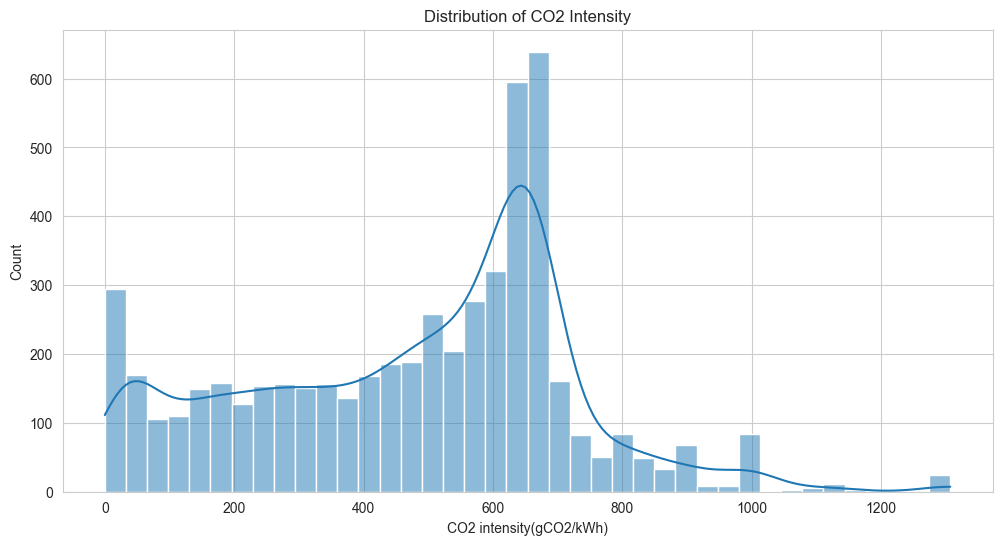

In [12]:
plt.figure()
sns.histplot(df['CO2 intensity(gCO2/kWh)'], bins=40, kde=True)
plt.title('Distribution of CO2 Intensity')
plt.show()

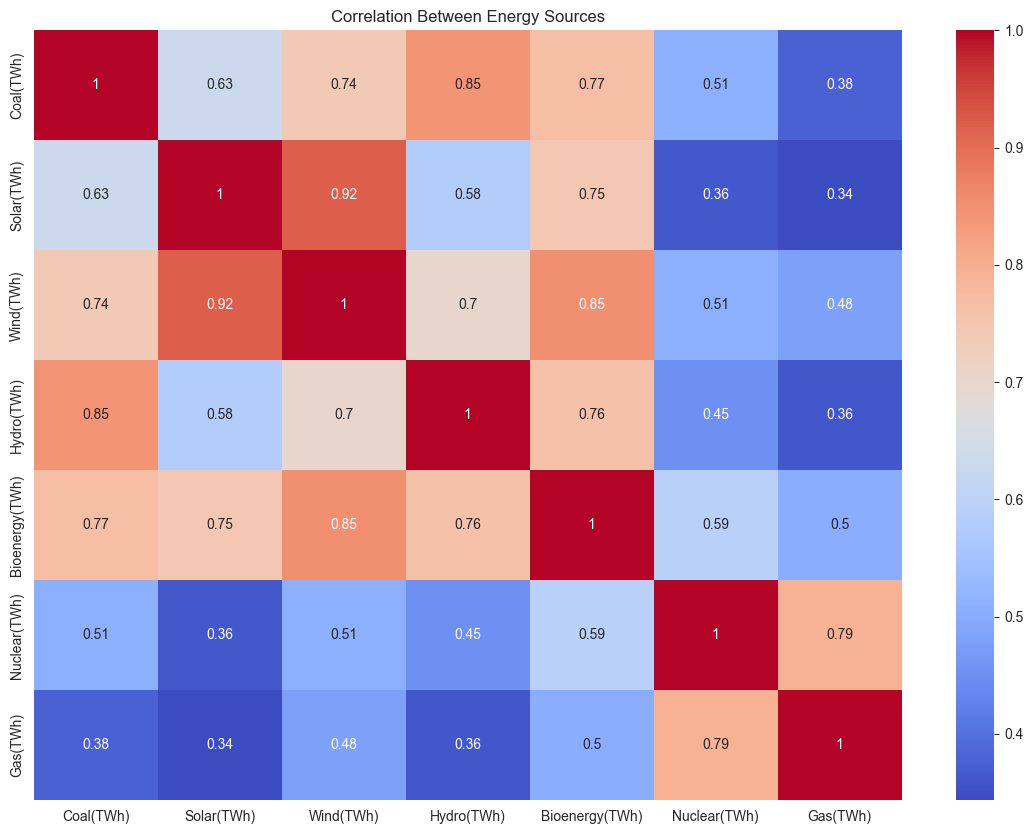

In [13]:
twh_cols = ['Coal(TWh)','Solar(TWh)','Wind(TWh)','Hydro(TWh)','Bioenergy(TWh)','Nuclear(TWh)','Gas(TWh)']

corr = df[twh_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Between Energy Sources')
plt.show()

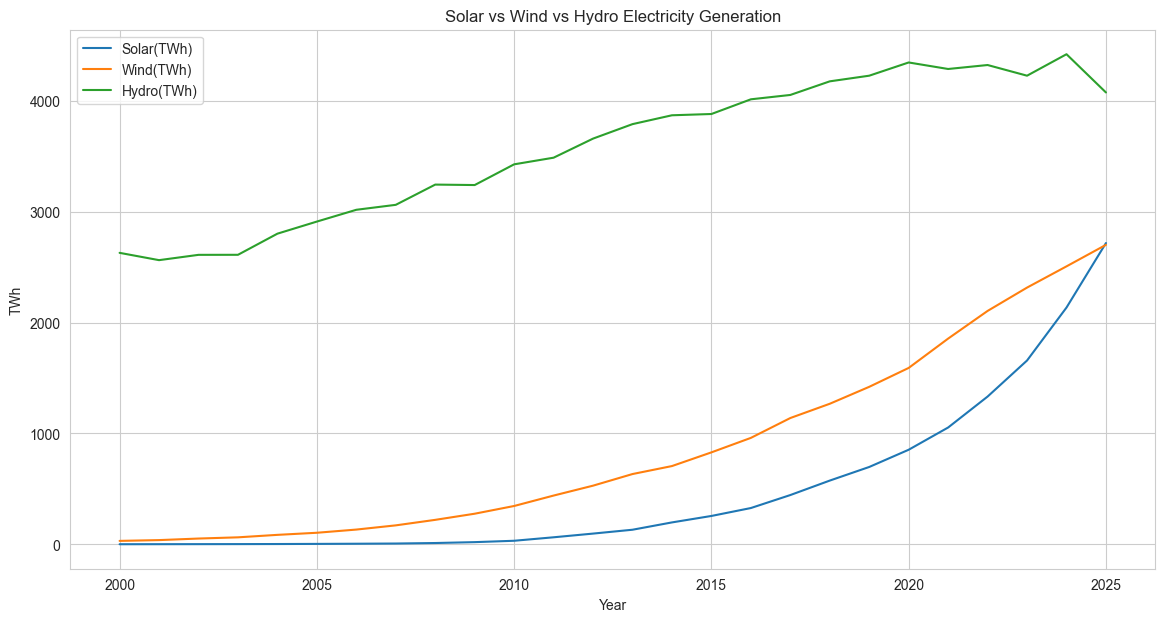

In [14]:
renewable_compare = (
    df.groupby('Year')[['Solar(TWh)', 'Wind(TWh)', 'Hydro(TWh)']]
    .sum()
)
renewable_compare.plot(figsize=(14,7))

plt.title('Solar vs Wind vs Hydro Electricity Generation')
plt.ylabel('TWh')
plt.show()

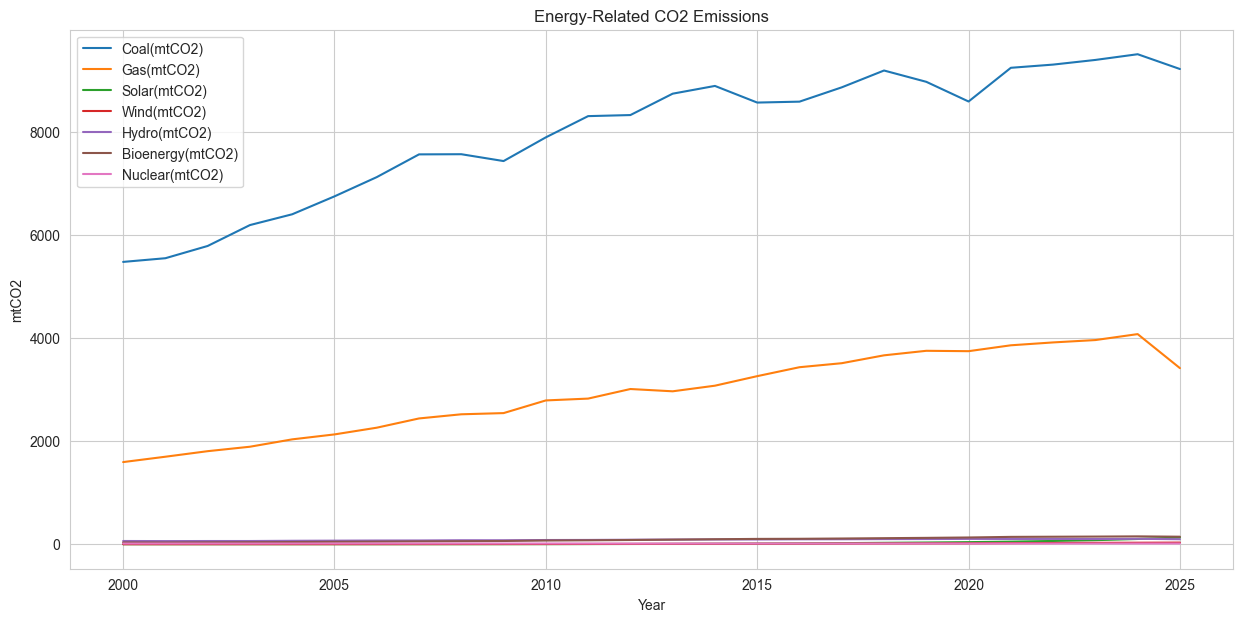

In [15]:
co2_cols = ['Coal(mtCO2)','Gas(mtCO2)','Solar(mtCO2)','Wind(mtCO2)','Hydro(mtCO2)','Bioenergy(mtCO2)','Nuclear(mtCO2)']

co2 = (
    df.groupby('Year')[co2_cols]
    .sum()
)

co2.plot(figsize=(15,7))

plt.title('Energy-Related CO2 Emissions')
plt.ylabel('mtCO2')
plt.show()

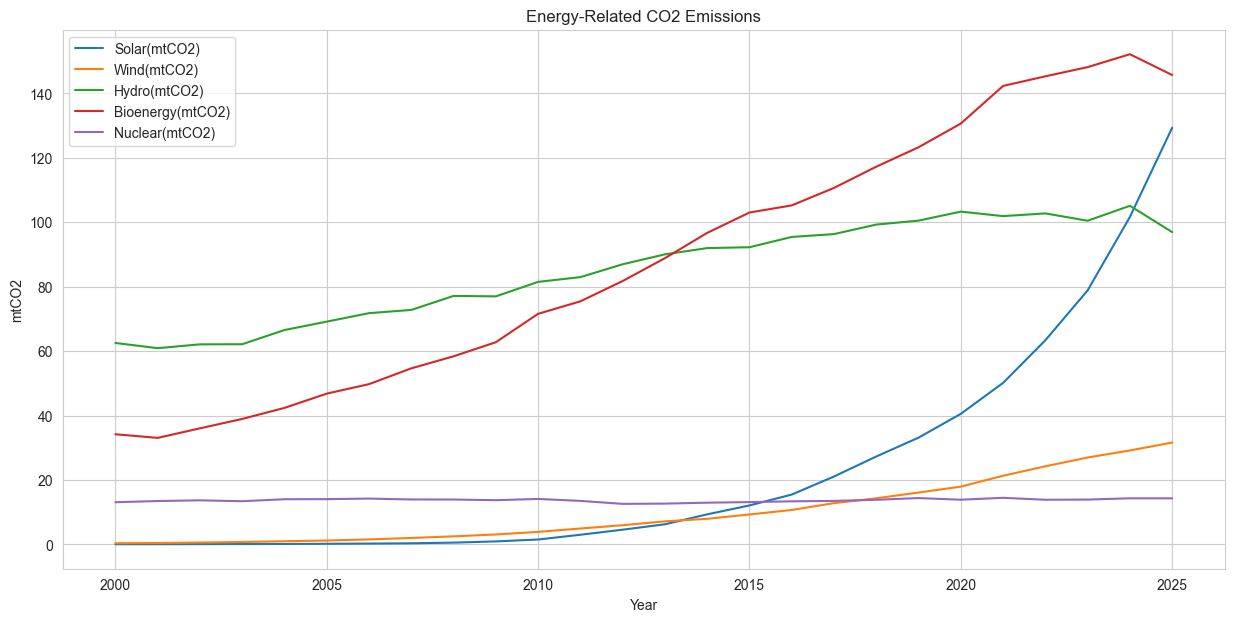

In [16]:
co2_cols_small = ['Solar(mtCO2)','Wind(mtCO2)','Hydro(mtCO2)','Bioenergy(mtCO2)','Nuclear(mtCO2)']

co2_small = (
    df.groupby('Year')[co2_cols_small]
    .sum()
)

co2_small.plot(figsize=(15,7))

plt.title('Energy-Related CO2 Emissions')
plt.ylabel('mtCO2')
plt.show()

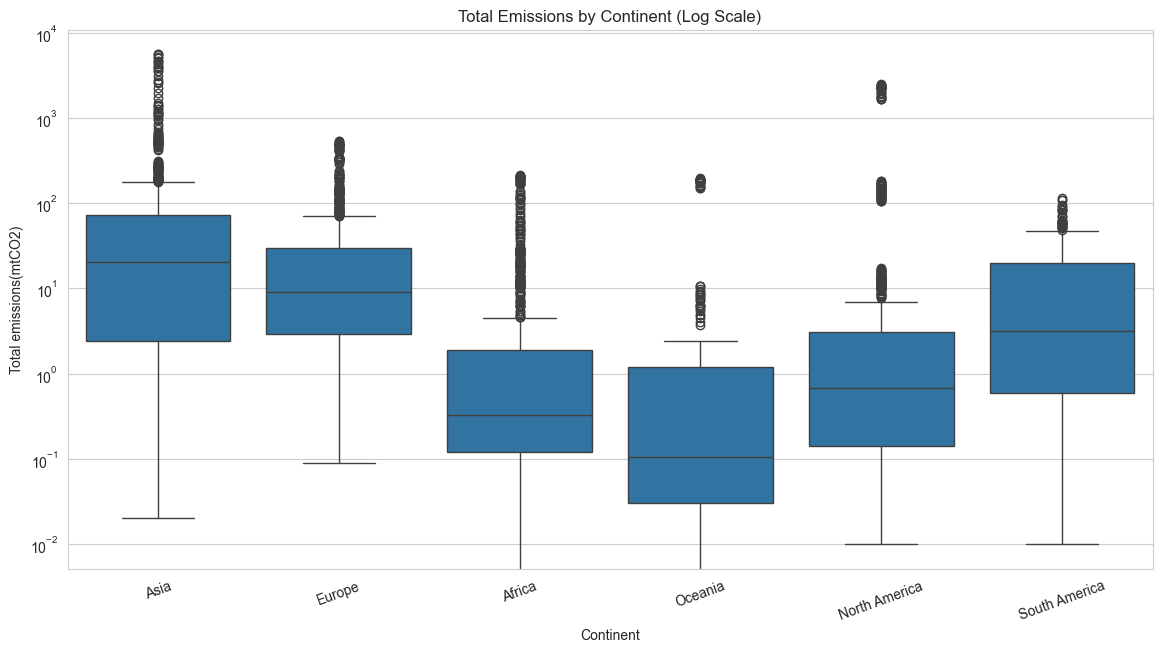

In [17]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Continent', y='Total emissions(mtCO2)')
plt.yscale('log')
plt.title('Total Emissions by Continent (Log Scale)')
plt.xticks(rotation=20)

plt.show()

C:\Users\iancu\AppData\Local\Temp\ipykernel_7400\4099299614.py:3: RuntimeWarning: divide by zero encountered in log10
  df_copy['Fossil(TWh)'] = df_copy['Fossil(TWh)'].apply(lambda x: np.log10(x))
C:\Users\iancu\AppData\Local\Temp\ipykernel_7400\4099299614.py:4: RuntimeWarning: divide by zero encountered in log10
  df_copy['Renewables(TWh)'] = df_copy['Renewables(TWh)'].apply(lambda x: np.log10(x))


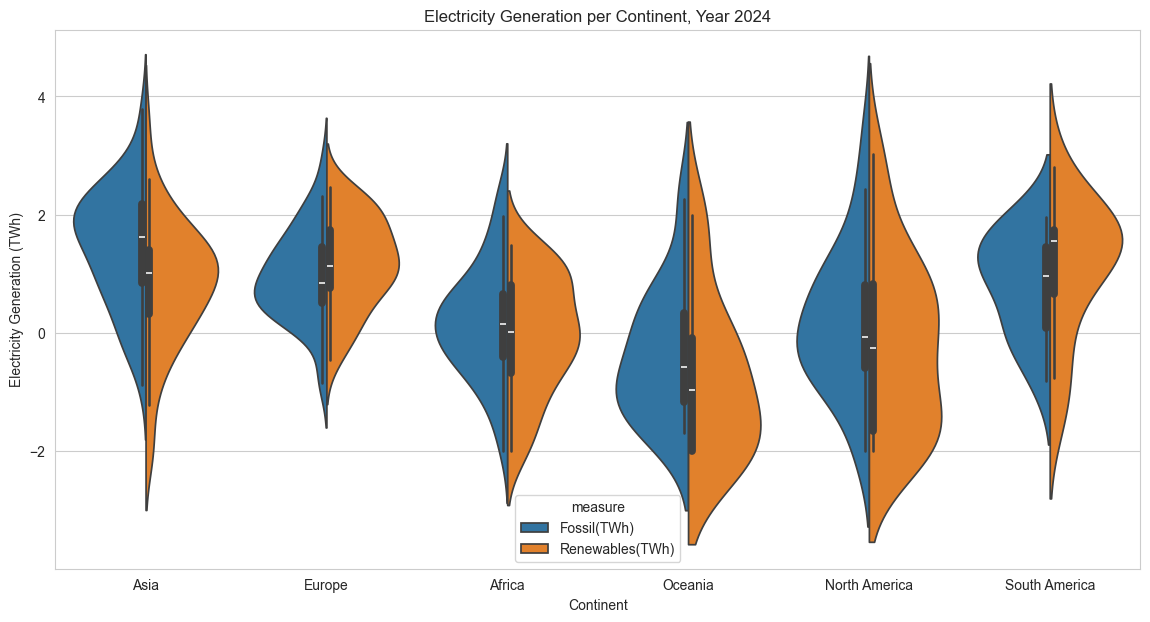

In [18]:
plt.figure(figsize=(14, 7))
df_copy = df.copy()
df_copy['Fossil(TWh)'] = df_copy['Fossil(TWh)'].apply(lambda x: np.log10(x))
df_copy['Renewables(TWh)'] = df_copy['Renewables(TWh)'].apply(lambda x: np.log10(x))
df_copy = df_copy[df_copy['Year'] == 2024]

pdf = df_copy.melt(id_vars=['Continent'], value_vars=['Fossil(TWh)', 'Renewables(TWh)'], var_name='measure', value_name='value')

sns.violinplot(data=pdf, x="Continent", y="value", hue="measure", split=True, density_norm="width")
plt.ylabel('Electricity Generation (TWh)')
plt.title('Electricity Generation per Continent, Year 2024')


plt.show()

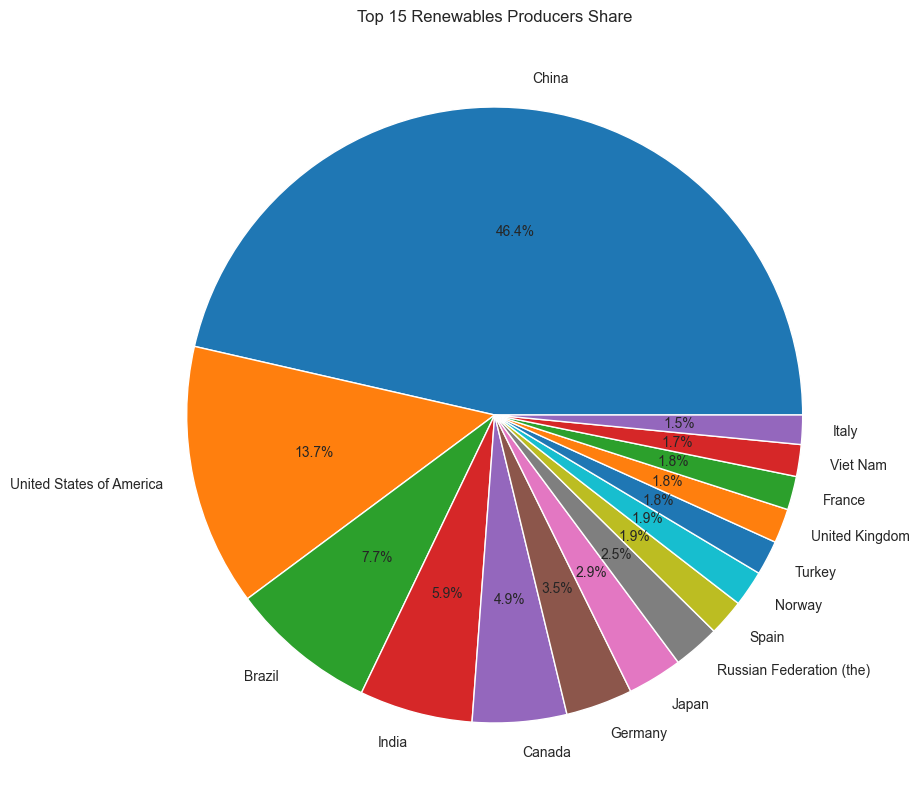

In [19]:
g9 = latest.groupby('Area')['Renewables(TWh)'].sum().nlargest(15)

plt.figure(figsize=(10, 10))
plt.pie(g9.values, labels=g9.index, autopct='%1.1f%%')
plt.title('Top 15 Renewables Producers Share')
plt.show()

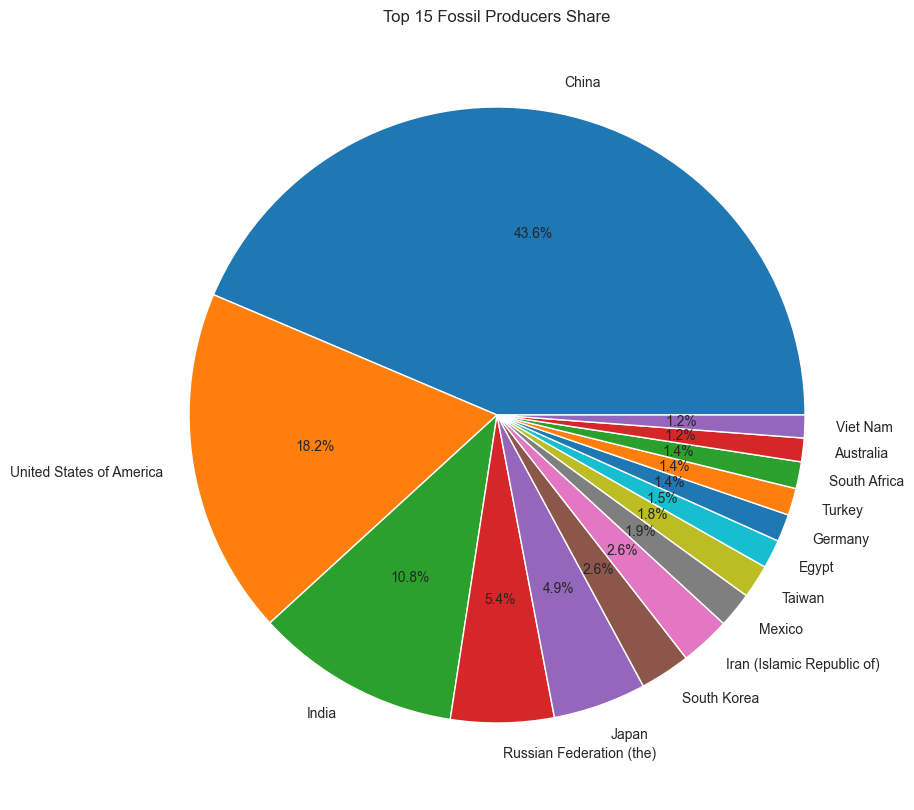

In [20]:
g10 = latest.groupby('Area')['Fossil(TWh)'].sum().nlargest(15)

plt.figure(figsize=(10, 10))
plt.pie(g10.values, labels=g10.index, autopct='%1.1f%%')
plt.title('Top 15 Fossil Producers Share')
plt.show()

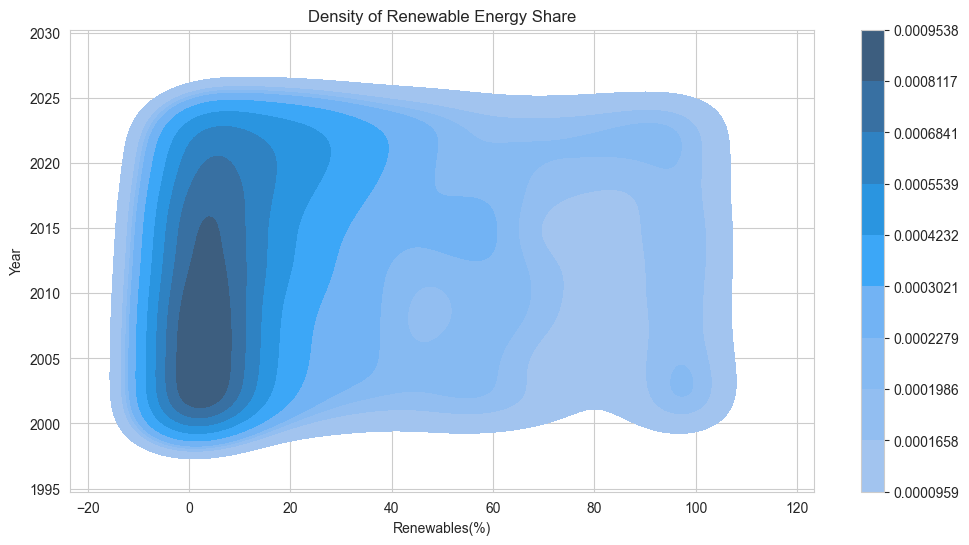

In [21]:
plt.figure()
sns.kdeplot(x=df['Renewables(%)'], y=df['Year'], fill=True, cbar=True)
plt.title('Density of Renewable Energy Share')
plt.show()

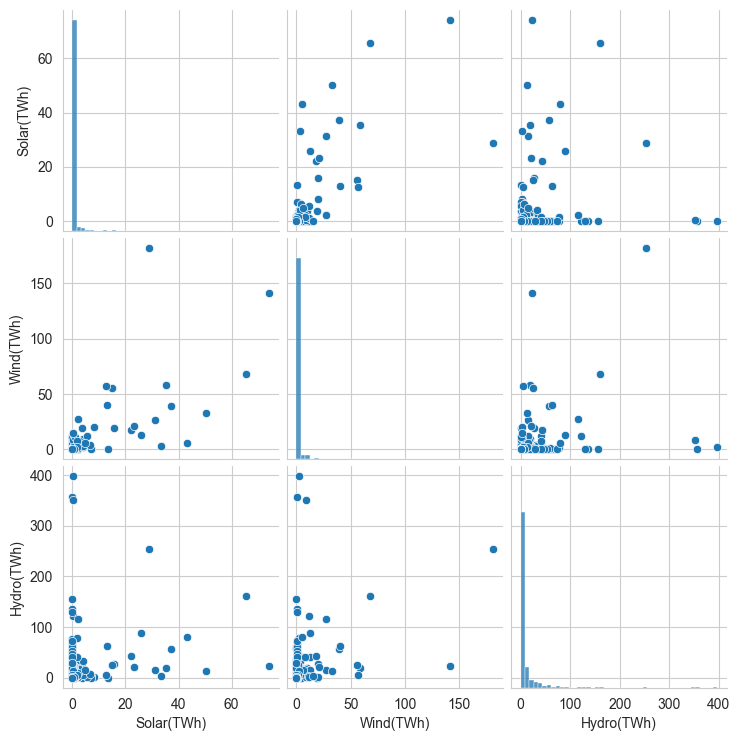

In [22]:
renewable_cols = ['Solar(TWh)','Wind(TWh)','Hydro(TWh)']
sample_df = df[renewable_cols].sample(min(500, len(df)), random_state=42)

pairplot = sns.pairplot(sample_df)
pairplot.fig.suptitle('')
plt.show()

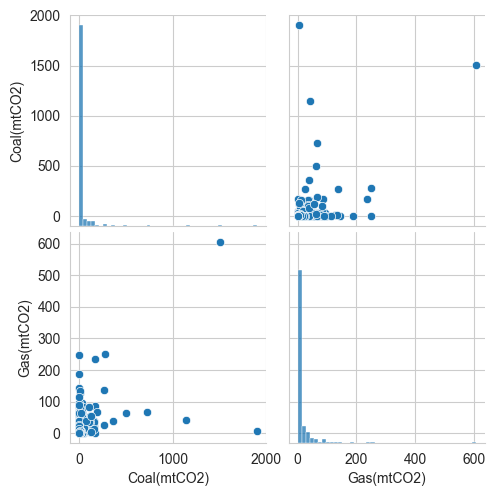

In [23]:
fossil_cols = ['Coal(mtCO2)','Gas(mtCO2)']
sample_df = df[fossil_cols].sample(min(500, len(df)), random_state=42)

pairplot = sns.pairplot(sample_df)
pairplot.fig.suptitle('')
plt.show()